In [47]:
import numpy as np
import matplotlib.pyplot as plt
import random
import copy

GRID_SIZE = 32
MAX_STEPS = 1500         
NUM_STATES = 10          
NUM_INPUTS = 3            
NUM_ACTIONS = 3         
POP_SIZE = 100            
NUM_GEN = 100           
MUTATION_RATE = 0.05     
ELITE_COUNT = 2           
TOURNAMENT_SIZE = 5      
NUM_RUNS = 20  

In [48]:
random.seed(42)
np.random.seed(42)

In [49]:
def generate_grid():
    grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
    
    for _ in range(int(GRID_SIZE**2 * 0.15)):
        x, y = random.randint(0, GRID_SIZE-1), random.randint(0, GRID_SIZE-1)
        if not (x == 0 and y == 0):
            grid[x, y] = 1
            
    for _ in range(25):
        cx, cy = random.randint(3, GRID_SIZE-4), random.randint(3, GRID_SIZE-4)
        for dx in range(-3, 4):
            for dy in range(-3, 4):
                if random.random() < 0.55:
                    nx, ny = cx+dx, cy+dy
                    if 0 <= nx < GRID_SIZE and 0 <= ny < GRID_SIZE and grid[nx, ny] == 0:
                        grid[nx, ny] = 2
    return grid

In [50]:
def create_random_genome():
    return [random.randint(0, (NUM_ACTIONS-1)*NUM_STATES + (NUM_STATES-1)) 
            for _ in range(NUM_STATES * NUM_INPUTS)]

def decode_genome(genome):
    fsm = []
    for s in range(NUM_STATES):
        row = []
        for inp in range(NUM_INPUTS):
            val = genome[s * NUM_INPUTS + inp]
            action = val // NUM_STATES
            next_state = val % NUM_STATES
            row.append((action, next_state))
        fsm.append(row)
    return fsm

In [51]:
def simulate_ant(genome, grid):
    fsm = decode_genome(genome)
    ant_x, ant_y = 0, 0
    direction = 0
    state = 0
    path = [(ant_x, ant_y)]
    food_collected = 0
    moves = [(-1, 0), (0, 1), (1, 0), (0, -1)] 

    if grid[ant_x, ant_y] == 2:
        grid[ant_x, ant_y] = 0
        food_collected += 1

    for _ in range(MAX_STEPS):
        nx, ny = ant_x + moves[direction][0], ant_y + moves[direction][1]

        if nx < 0 or nx >= GRID_SIZE or ny < 0 or ny >= GRID_SIZE or grid[nx, ny] == 1:
            sensor = 1 
        elif grid[nx, ny] == 2:
            sensor = 0  
        else:
            sensor = 2 

        action, next_state = fsm[state][sensor]
        state = next_state

        if action == 0:  
            if 0 <= nx < GRID_SIZE and 0 <= ny < GRID_SIZE and grid[nx, ny] != 1:
                ant_x, ant_y = nx, ny
                path.append((ant_x, ant_y))
                if grid[ant_x, ant_y] == 2:
                    grid[ant_x, ant_y] = 0
                    food_collected += 1
        elif action == 1:  
            direction = (direction - 1) % 4
        elif action == 2:  
            direction = (direction + 1) % 4

    return food_collected, path

In [52]:
def calculate_diversity(population):
    if len(population) < 2:
        return 0.0
    
    total_diff = 0
    comparisons = 0
    genome_len = len(population[0])

    for i in range(len(population)):
        for j in range(i + 1, len(population)):
            diff = sum(a != b for a, b in zip(population[i], population[j]))
            total_diff += diff / genome_len
            comparisons += 1
    
    return total_diff / comparisons if comparisons > 0 else 0.0

In [ ]:
def run_ga(fixed_grid, total_food, track_metrics=True):
    population = [create_random_genome() for _ in range(POP_SIZE)]
    
    best_ever_genome = None
    best_ever_path = []
    best_ever_fitness = -1
    
    fitness_history = []
    avg_fitness_history = []
    diversity_history = []
    
    for gen in range(NUM_GEN):
        results = []
        for genome in population:
            grid_copy = fixed_grid.copy()
            fitness, path = simulate_ant(genome, grid_copy)
            results.append((fitness, path, genome))
        
        results.sort(key=lambda x: x[0], reverse=True)
        best_fit, best_path, best_genome = results[0]
        avg_fit = np.mean([r[0] for r in results])
        
        if best_fit > best_ever_fitness:
            best_ever_fitness = best_fit
            best_ever_path = best_path.copy()
            best_ever_genome = best_genome.copy()
        
        if track_metrics:
            fitness_history.append(best_fit)
            avg_fitness_history.append(avg_fit)
            diversity = calculate_diversity([r[2] for r in results])
            diversity_history.append(diversity)
        
        new_population = [copy.deepcopy(ind[2]) for ind in results[:ELITE_COUNT]]
        
        while len(new_population) < POP_SIZE:
            contenders = random.sample(results, TOURNAMENT_SIZE)
            p1 = max(contenders, key=lambda x: x[0])[2]
            contenders = random.sample(results, TOURNAMENT_SIZE)
            p2 = max(contenders, key=lambda x: x[0])[2]
            
            child = p1.copy()
            cross_point = random.randint(0, len(child)-1)
            child[cross_point:] = p2[cross_point:]
            
            for i in range(len(child)):
                if random.random() < MUTATION_RATE:
                    child[i] = random.randint(0, (NUM_ACTIONS-1)*NUM_STATES + (NUM_STATES-1))
            
            new_population.append(child)
        
        population = new_population
    
    if track_metrics:
        return (best_ever_genome, best_ever_path, best_ever_fitness, 
                fitness_history, avg_fitness_history, diversity_history)
    else:
        return best_ever_genome, best_ever_path, best_ever_fitness

In [54]:
def visualize(original_grid, path, food_collected, total_food):
    fig, ax = plt.subplots(figsize=(9, 9))
    cmap = plt.cm.colors.ListedColormap(['#F5F5F5', '#FF0000', '#00FF00'])
    ax.imshow(original_grid, cmap=cmap, interpolation='nearest')

    xs, ys = zip(*path)
    ax.plot(ys, xs, 'b-', linewidth=2.5, alpha=0.8, label='Путь муравья')
    ax.plot(ys[0], xs[0], 'bo', markersize=10, label='Старт')
    ax.plot(ys[-1], xs[-1], 'mo', markersize=10, label='Финиш')

    ax.set_title(f"Искусственный муравей | Собрано: {food_collected}/{total_food} еды", fontsize=14, pad=10)
    ax.set_xticks(np.arange(-.5, GRID_SIZE, 1), minor=True)
    ax.set_yticks(np.arange(-.5, GRID_SIZE, 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.legend(loc='upper right')
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

In [61]:
def plot_convergence_aggregated(all_results, total_food):
    best_curves = np.array([r['fitness_history'] for r in all_results])  # (20, 100)
    avg_curves = np.array([r['avg_fitness_history'] for r in all_results])
    
    generations = range(1, NUM_GEN + 1)
    
    best_mean = np.mean(best_curves, axis=0)
    best_std = np.std(best_curves, axis=0)
    avg_mean = np.mean(avg_curves, axis=0)
    
    plt.figure(figsize=(11, 6))
    
    plt.plot(generations, best_mean, 'r-', linewidth=2.5, label='Лучшая особь')
    plt.fill_between(generations, 
                     np.clip(best_mean - best_std, 0, None), 
                     best_mean + best_std, 
                     color='red', alpha=0.2, label='±1 sigma')
    
    plt.plot(generations, avg_mean, 'b--', linewidth=1.5, label='Среднее по популяции')
    plt.fill_between(generations, 
                     np.clip(avg_mean - np.std(avg_curves, axis=0), 0, None), 
                     avg_mean + np.std(avg_curves, axis=0), 
                     color='blue', alpha=0.1)
    
    plt.axhline(y=total_food, color='green', linestyle=':', linewidth=1, 
                label=f'Всего еды: {total_food}', alpha=0.6)
    
    plt.xlabel('Поколение', fontsize=11)
    plt.ylabel('Собрано еды', fontsize=11)
    plt.title('Сходимость ГА (ср. по 20 прогонам)', fontsize=13, pad=15)
    plt.legend(fontsize=9, loc='lower right')
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    
def plot_diversity_aggregated(all_results):
    div_curves = np.array([r['diversity_history'] for r in all_results])
    
    generations = range(1, NUM_GEN + 1)
    div_mean = np.mean(div_curves, axis=0)
    div_std = np.std(div_curves, axis=0)
    
    plt.figure(figsize=(10, 5))
    plt.plot(generations, div_mean, 'purple', linewidth=2.5, label='Разнообразие')
    plt.fill_between(generations, 
                     np.clip(div_mean - div_std, 0, 1), 
                     np.clip(div_mean + div_std, 0, 1), 
                     color='purple', alpha=0.25, label='±1 sigma')

    plt.xlabel('Поколение', fontsize=11)
    plt.ylabel('Разнообразие (0–1)', fontsize=11)
    plt.title('Генетическое разнообразие (ср. по 20 прогонам)', fontsize=13, pad=15)
    plt.legend(fontsize=9)
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

Всего еды: 397
Прогон  1/20...
Прогон Завершён. Съедено: 329/397; Разнообразие: 0.242
Прогон  2/20...
Прогон Завершён. Съедено: 319/397; Разнообразие: 0.217
Прогон  3/20...
Прогон Завершён. Съедено: 288/397; Разнообразие: 0.239
Прогон  4/20...
Прогон Завершён. Съедено: 313/397; Разнообразие: 0.363
Прогон  5/20...
Прогон Завершён. Съедено: 229/397; Разнообразие: 0.250
Прогон  6/20...
Прогон Завершён. Съедено: 327/397; Разнообразие: 0.158
Прогон  7/20...
Прогон Завершён. Съедено: 328/397; Разнообразие: 0.237
Прогон  8/20...
Прогон Завершён. Съедено: 288/397; Разнообразие: 0.138
Прогон  9/20...
Прогон Завершён. Съедено: 310/397; Разнообразие: 0.177
Прогон 10/20...
Прогон Завершён. Съедено: 296/397; Разнообразие: 0.231
Прогон 11/20...
Прогон Завершён. Съедено: 295/397; Разнообразие: 0.190
Прогон 12/20...
Прогон Завершён. Съедено: 315/397; Разнообразие: 0.279
Прогон 13/20...
Прогон Завершён. Съедено: 258/397; Разнообразие: 0.222
Прогон 14/20...
Прогон Завершён. Съедено: 290/397; Разнообрази

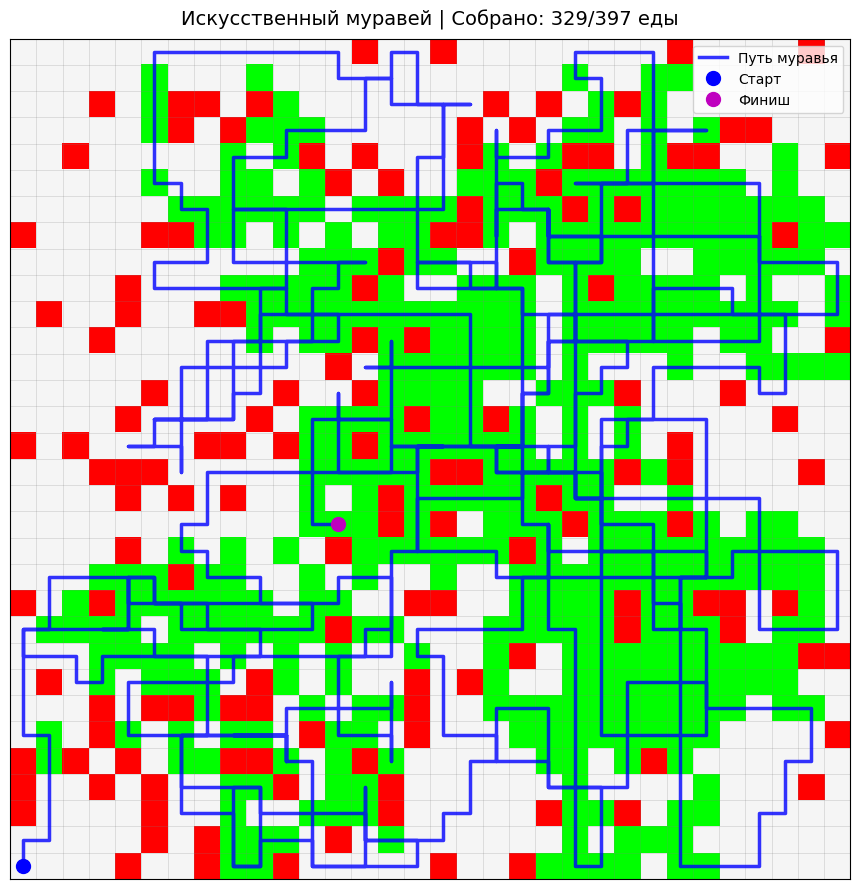

In [56]:
np.random.seed(42)
random.seed(42)
original_grid = generate_grid()
total_food = np.count_nonzero(original_grid == 2)

print(f"Всего еды: {total_food}")

all_results = []

for run in range(NUM_RUNS):
    print(f"Прогон {run+1:2d}/{NUM_RUNS}")
    
    result = run_ga(original_grid, total_food, track_metrics=True)
    genome, path, fitness, fit_hist, avg_hist, div_hist = result
    
    all_results.append({
        'run': run + 1,
        'fitness': fitness,
        'path': path,
        'genome': genome,
        'fitness_history': fit_hist,
        'avg_fitness_history': avg_hist,
        'diversity_history': div_hist
    })
    
    print(f"Прогон Завершён. Съедено: {fitness:3d}/{total_food}; "
            f"Разнообразие: {div_hist[-1]:.3f}")

fitnesses = [r['fitness'] for r in all_results]
best_run = max(all_results, key=lambda x: x['fitness'])

print(f"\nСтатистика по {NUM_RUNS} прогонам:")
print(f"Лучший: {best_run['fitness']} еды (прогон #{best_run['run']})")
print(f"Среднее: {np.mean(fitnesses):.2f} ± {np.std(fitnesses):.2f}")
print(f"Диапазон: {min(fitnesses)} — {max(fitnesses)}")
print(f"Медиана: {np.median(fitnesses)}")

print("Отрисовка лучшего маршрута...")
visualize(original_grid, best_run['path'], best_run['fitness'], total_food)

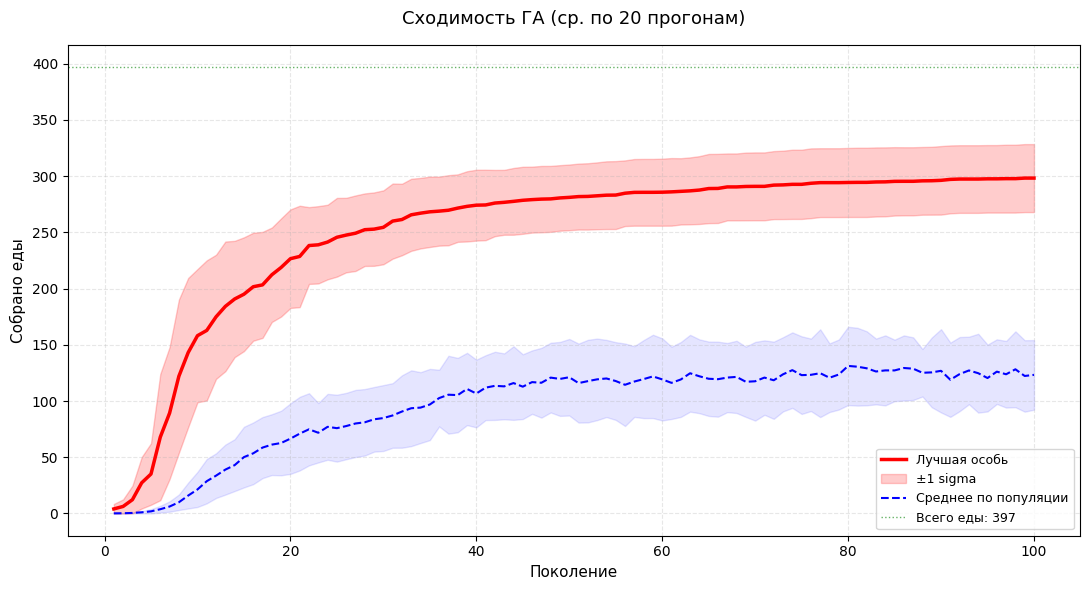

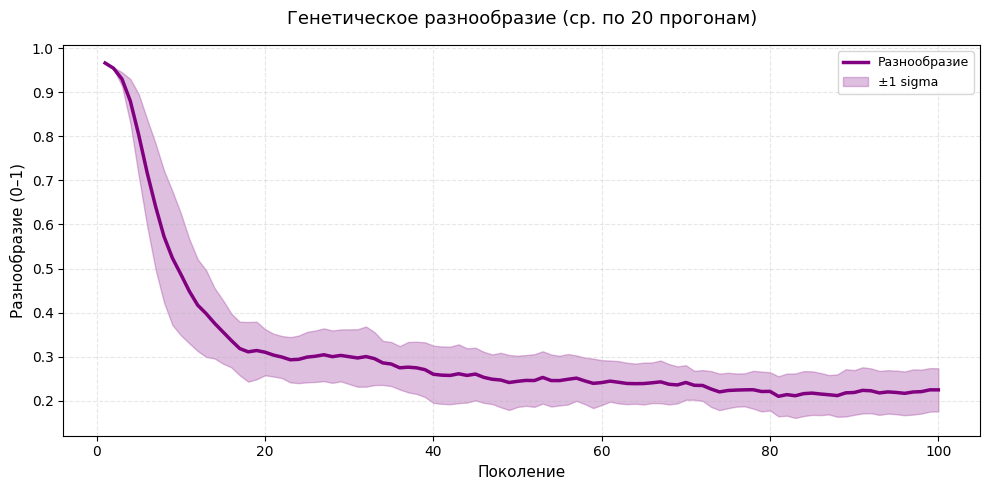

In [62]:
plot_convergence_aggregated(all_results, total_food)
plot_diversity_aggregated(all_results)